Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 42735.4102 - val_loss: 21446.7793
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 9993.6758 - val_loss: 4633.8101
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5552.1313 - val_loss: 3998.7520
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3479.9272 - val_loss: 3180.0791
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2863.2080 - val_loss: 2823.3586
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2544.0842 - val_loss: 2344.3257
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2237.6946 - val_loss: 2048.4873
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1911.7402 - val_loss: 1734.3672
Epoch 9/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1653.2878 - val_loss: 1683.4990
Epoch 10/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1463.1743 - val_loss: 1334.1697
Epoch 11/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1161.8080 - val_loss: 1064

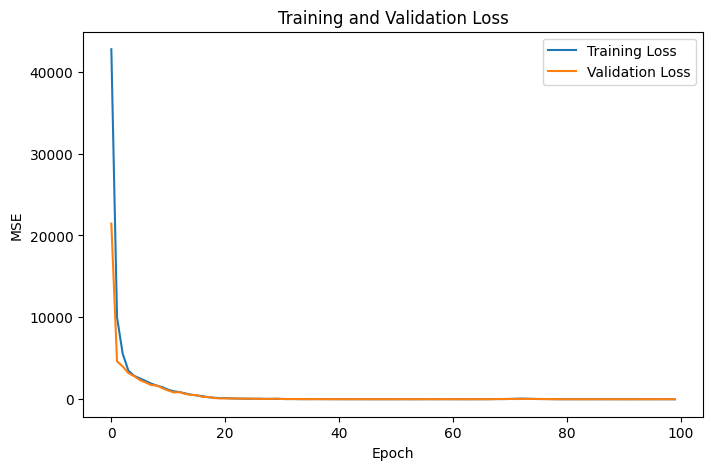

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential,Model
from tensorflow.keras.layers import Dense,Input
from tensorflow.keras.optimizers import Adam

# সহজ equation
def simple_equation(x):
    # return 2 * x**2 + 3 * x + 5
    return 5 * x **2 + 10 * x+5

# Dataset তৈরি
def generate_data(n=500):
    x = np.random.randint(-10, 10, n)
    y = simple_equation(x)
    return x.reshape(-1,1), y

# Train, validation, test split
def train_val_test_split(x, y, train_ratio=0.7, val_ratio=0.1):
    n = len(x)
    train_n = int(n * train_ratio)
    val_n = int(n * val_ratio)
    return (x[:train_n], y[:train_n]), (x[train_n:train_n+val_n], y[train_n:train_n+val_n]), (x[train_n+val_n:], y[train_n+val_n:])

# Model তৈরি
def build_model():
     
    inputs = Input((1,))
    h1 = Dense(64 , activation= 'relu') (inputs)
    h2 = Dense(64 , activation='relu') (h1)
    h3 = Dense(64, activation='relu') (h2)
    # h4 = Dense(128 , activation='relu') (h3)
    # h5 = Dense(64 , activation='relu') (h4)
    outputs = Dense(1 , name = 'output_layer')(h3)
    model = Model(inputs , outputs)
    model.compile(optimizer=Adam(0.01), loss='mse')
    return model

# Main function
def main():
    x, y = generate_data()
    (trainX, trainY), (valX, valY), (testX, testY) = train_val_test_split(x, y)

    model = build_model()
    history = model.fit(trainX, trainY,
                        validation_data=(valX, valY),
                        epochs=100,
                        batch_size=32,
                        verbose=1)
    
    # Test evaluation

    test_loss = model.evaluate(testX, testY, verbose=0)
    print(f"Test MSE: {test_loss:.4f}")

    # Plot training & validation loss
    plt.figure(figsize=(8,5))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('MSE')
    plt.legend()
    plt.show()

if __name__ == "__main__":
    main()